# Variable Time Shifts

This notebook contains an example of performing a variable time shift.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time 

import WDM
from WDM.code.discrete_wavelet_transform import WDM 

Let's start by creating an example signal. We will use a simple sine-Gaussian.

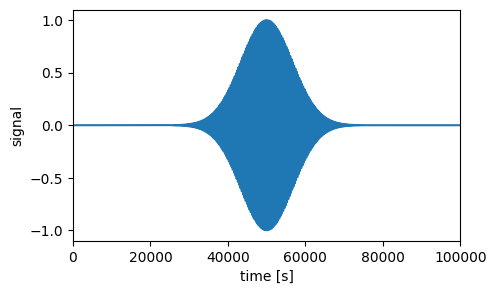

In [2]:
fs = 0.2    # sampling frequency [Hz]
T  = 1.0e5  # duration [s]
f0 = 3.0e-3 # central frequency [Hz]
w  = T/15.  # duration [s]

sine_gauss = lambda t: np.exp(-0.5*((t-T/2.)/w)**2)*np.sin(2*np.pi*f0*t)

times = np.arange(0, T, 1/fs)
signal = sine_gauss(times)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(times, signal)
ax.set_xlim(0, T)
ax.set_xlabel(r'time [s]')
ax.set_ylabel('signal')
plt.show()

Now we set up the WDM transform object. We use 200 frequency slices.

In [3]:
N, Nf= times.shape[0], 200

wdm = WDM.WDM_transform(dt=1/fs, Nf=Nf, N=N, q=32, calc_m0=True)

print(wdm)

WDM_transform(Nf=200, N=20000, q=32, d=4, A_frac=0.25, calc_m0=True)
self.Nt = 100 time cells
self.Nf = 200 frequency cells
self.dT = 1000.0 time resolution
self.dF = 0.0005 frequency resolution
self.dt = 5.0 time series cadence
self.df = 1e-05 time series fft frequency resolution
self.K = 12800 window length


Now take the discrete wavelet transform of our signal.

In [4]:
w = wdm(signal)

Just to check that everything is working, let's plot the time-frequency coefficients.

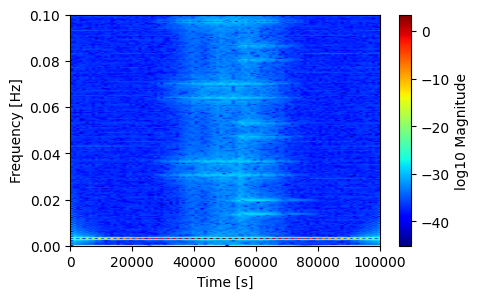

In [5]:
fig, ax = plt.subplots(figsize=(5,3))
im = ax.imshow(np.log(np.abs(w.T)),
          aspect='auto', origin='lower', cmap='jet',
          extent=[0., wdm.T, 0., wdm.f_Ny])
fig.colorbar(im, label='log10 Magnitude', ax=ax)
ax.set_xlabel(r'Time [s]')
ax.set_ylabel(r'Frequency [Hz]')
plt.show()

In order to use the time-delay filters to peform time shifts using the `WDM` package it is first necessary to call the `build_time_delay_filter_interpolants` method. The arguments are the maximum lag index `L` and the number of interpolation points `N`.

In [6]:
L = 25  # the maximum lag index
N = 10  # the number of interpolation points
wdm.build_time_delay_filter_interpolants(L, N)

tn = np.arange(wdm.Nt)*wdm.dT

First, let's consider the case of a constant time shift $\delta$.

In [7]:
delta_constant = lambda t: (T/10.)*np.ones_like(t)

We will now apply this time shift to the signal using two methods.
First, as a check, we do this simply in the time domain by interpoating the original signal.
Second, using the `WDM` package, we apply the shift in the time-frequency domain using the time-delay filters.

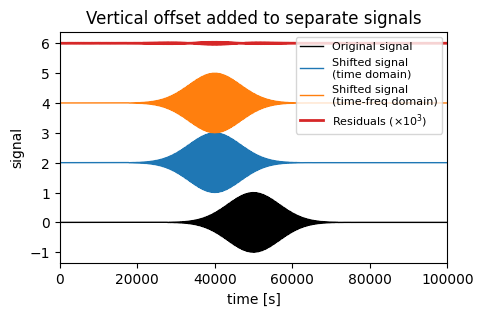

In [8]:
shifted_signal_constant_t = np.interp(times + delta_constant(times), 
                                      times, 
                                      signal)

w_shifted_constant = wdm.apply_variable_time_shift(w, delta_constant(tn))
shifted_signal_constant_tf = wdm.idwt(w_shifted_constant)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(times, signal, 
        c='k', lw=1, label='Original signal')
ax.plot(times, 2+shifted_signal_constant_t, 
        c='C0', lw=1, label='Shifted signal\n(time domain)')
ax.plot(times, 4+shifted_signal_constant_tf, 
        c='C1', lw=1, label='Shifted signal\n(time-freq domain)')
ax.plot(times, 6+1000*(shifted_signal_constant_t-shifted_signal_constant_tf), 
        c='C3', lw=2, label=r'Residuals ($\times 10^3$)')
ax.set_xlim(0, T)
ax.set_xlabel(r'time [s]')
ax.set_ylabel('signal')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Vertical offset added to separate signals')
plt.show()

Second, let's consider the case of a variable time shift $\delta(t)$.

In [9]:
delta_variable = lambda t: (T/10.)+(T/1000.)*t/T

We now apply this variable time shift using the same two methods as before.

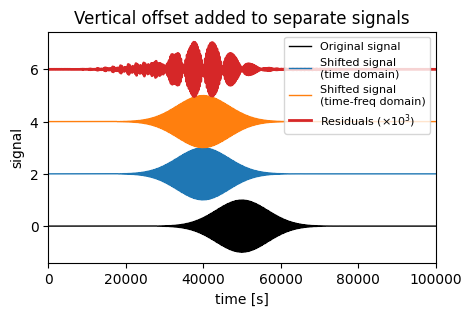

In [10]:
shifted_signal_variable_t = np.interp(times + delta_variable(times), 
                                      times, 
                                      signal)

w_shifted_variable = wdm.apply_variable_time_shift(w, delta_variable(tn))
shifted_signal_variable_tf = wdm.idwt(w_shifted_variable)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(times, signal, 
        c='k', lw=1, label='Original signal')
ax.plot(times, 2+shifted_signal_variable_t, 
        c='C0', lw=1, label='Shifted signal\n(time domain)')
ax.plot(times, 4+shifted_signal_variable_tf, 
        c='C1', lw=1, label='Shifted signal\n(time-freq domain)')
ax.plot(times, 6+1000*(shifted_signal_variable_t-shifted_signal_variable_tf), 
        c='C3', lw=2, label=r'Residuals ($\times 10^3$)')
ax.set_xlim(0, T)
ax.set_xlabel(r'time [s]')
ax.set_ylabel('signal')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Vertical offset added to separate signals')
plt.show()